# 🔥 Predicción de Incendios Forestales en EE.UU. (2014-2025)

Dataset: [US Wildfire Dataset (2014-2025)](https://www.kaggle.com/datasets/firecastrl/us-wildfire-dataset)

## Descripción del dataset

El dataset **US Wildfire** fue obtenido de Kaggle y contiene registros climáticos y geográficos de puntos relevados a lo largo de los Estados Unidos, con el objetivo de predecir si en una ubicación y momento dados ocurrió o no un incendio forestal.

- **Variable objetivo:** `Wildfire` (indica si hubo incendio o no)

## Justificación de la elección

Los incendios forestales representan una de las catástrofes naturales más devastadoras del planeta, con un impacto directo sobre ecosistemas, comunidades y el cambio climático. EE.UU. es uno de los países más afectados, especialmente en el oeste del país.

Este dataset permite abordar un problema de **clasificación binaria** real y relevante: predecir si las condiciones climáticas y ambientales de un lugar determinado son propicias para que ocurra un incendio. Las variables disponibles cubren factores clave como temperatura, humedad, viento y radiación solar, lo que lo convierte en un dataset ideal para aplicar técnicas de Machine Learning supervisado.

In [1]:
# ==========================================================
# IMPORTO LAS LIBRERÍAS PRINCIPALES
# ==========================================================

# importamos librerías para descargar datasets desde kaggle
from pathlib import Path
import kagglehub

# Importamos librerías generales para trabajar con datos
import os
import pandas as pd

# Importamos matplotlib y seaborn para realizar gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas para separar datos y validar modelos
from sklearn.model_selection import train_test_split, cross_val_score

# Herramientas para construir pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Herramientas de preprocesamiento
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Modelos de clasificación
from sklearn.linear_model import LogisticRegression

# Métricas de evaluación para clasificación
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

#import joblib

# Configuración de estilo para los gráficos
sns.set(style='whitegrid')
# Configuración general para que pandas muestre mejor las tablas
pd.set_option("display.max_columns", None)

In [2]:
# ==========================================================
# CARGO EL DATASET
# ==========================================================

PROJECT_ROOT = Path.cwd()
DATASET_PATH = PROJECT_ROOT / "data" / "Wildfire_Dataset.csv"

# Si el dataset no existe localmente, lo descargamos desde Kaggle
if not DATASET_PATH.exists():
    print("No se encontró el dataset localmente.")
    print("Descargando el dataset desde Kaggle...")

    downloaded_path = kagglehub.dataset_download(
        "firecastrl/us-wildfire-dataset",
        path="Wildfire_Dataset.csv",
        output_dir=str(PROJECT_ROOT / "data"),
    )

    DATASET_PATH = Path(downloaded_path)
    print(f"Dataset descargado en: {DATASET_PATH}")
else:
    print(f"Dataset encontrado en: {DATASET_PATH}")
df = pd.read_csv(DATASET_PATH)

Dataset encontrado en: d:\Trabajo\Cursos\GitHub\Proyecto-4\machine-learning-wildfires\data\Wildfire_Dataset.csv


In [3]:
# ==========================================================
# ANALIZO EL DATASET
# ==========================================================

print("Dimensiones del dataset:", df.shape)
df.info(show_counts=True)

Dimensiones del dataset: (9509925, 19)
<class 'pandas.DataFrame'>
RangeIndex: 9509925 entries, 0 to 9509924
Data columns (total 19 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   latitude   9509925 non-null  float64
 1   longitude  9509925 non-null  float64
 2   datetime   9509925 non-null  str    
 3   Wildfire   9509925 non-null  str    
 4   pr         9509925 non-null  float64
 5   rmax       9509925 non-null  float64
 6   rmin       9509925 non-null  float64
 7   sph        9509925 non-null  float64
 8   srad       9509925 non-null  float64
 9   tmmn       9509925 non-null  float64
 10  tmmx       9509925 non-null  float64
 11  vs         9509925 non-null  float64
 12  bi         9509925 non-null  float64
 13  fm100      9509925 non-null  float64
 14  fm1000     9509925 non-null  float64
 15  erc        9509925 non-null  float64
 16  etr        9509925 non-null  float64
 17  pet        9509925 non-null  float64
 18  vpd        950

## Variables del dataset

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `latitude` | float64 | Latitud geográfica del punto |
| `longitude` | float64 | Longitud geográfica del punto |
| `datetime` | object | Fecha y hora del registro |
| `Wildfire` | object | Variable objetivo: incendio o no |
| `pr` | float64 | Precipitación |
| `rmax` | float64 | Humedad relativa máxima |
| `rmin` | float64 | Humedad relativa mínima |
| `sph` | float64 | Humedad específica |
| `srad` | float64 | Radiación solar |
| `tmmn` | float64 | Temperatura mínima |
| `tmmx` | float64 | Temperatura máxima |
| `vs` | float64 | Velocidad del viento |
| `bi` | float64 | Índice de quema (Burning Index) |
| `fm100` | float64 | Humedad del combustible muerto a 100 horas |
| `fm1000` | float64 | Humedad del combustible muerto a 1000 horas |
| `erc` | float64 | Componente de liberación de energía |
| `etr` | float64 | Evapotranspiración de referencia |
| `pet` | float64 | Evapotranspiración potencial |
| `vpd` | float64 | Déficit de presión de vapor |

In [4]:
# --------------------------------------------------------------
# Primer vistazo del dataset
# --------------------------------------------------------------
print('\nPrimeras 5 filas del dataset:')
display(df.head())


Primeras 5 filas del dataset:


,latitude,longitude,datetime,Wildfire,pr,rmax,rmin,sph,srad,tmmn,tmmx,vs,bi,fm100,fm1000,erc,etr,pet,vpd
0,48.128431,-97.276685,2018-08-15,No,0.0,78.6,14.9,0.00582,272.6,282.0,301.6,3.0,40.0,10.2,12.2,54.0,7.5,5.5,1.59
1,48.128431,-97.276685,2018-08-16,No,0.0,80.4,13.9,0.00676,264.0,283.9,304.9,3.0,40.0,9.7,12.0,56.0,8.2,5.9,1.93
2,48.128431,-97.276685,2018-08-17,No,0.0,70.9,20.4,0.00672,265.6,285.8,300.7,3.1,40.0,9.2,11.9,56.0,7.2,5.3,1.51
3,48.128431,-97.276685,2018-08-18,No,5.0,65.2,19.4,0.00756,261.4,289.0,303.3,5.1,0.0,9.9,12.0,40.0,10.0,6.9,1.85
4,48.128431,-97.276685,2018-08-19,No,0.0,100.0,42.2,0.00895,166.8,283.8,296.5,4.7,41.0,11.8,12.1,47.0,4.6,3.4,0.66


In [5]:
print('\nResumen estadístico de las variables numéricas:')
display(df.describe())


Resumen estadístico de las variables numéricas:


,latitude,longitude,pr,rmax,rmin,sph,srad,tmmn,tmmx,vs,bi,fm100,fm1000,erc,etr,pet,vpd
count,9.509925e+06,9.509925e+06,9.509925e+06,9.509925e+06,9.509925e+06,9.509925e+06,9.509925e+06,9.509925e+06,9.509925e+06,9.509925e+06,9.509925e+06,9.509925e+06,9.509925e+06,9.509925e+06,9.509925e+06,9.509925e+06,9.509925e+06
mean,3.914362e+01,-1.064347e+02,9.036891e+01,1.645754e+02,1.220707e+02,8.864304e+01,3.091587e+02,3.682137e+02,3.821415e+02,9.239142e+01,1.221668e+02,1.013892e+02,1.030986e+02,1.320922e+02,9.425599e+01,9.275527e+01,8.976546e+01
std,5.267332e+00,1.456924e+01,1.701836e+03,1.698086e+03,1.700272e+03,1.701914e+03,1.692717e+03,1.687376e+03,1.686659e+03,1.701719e+03,1.700336e+03,1.701257e+03,1.701169e+03,1.699822e+03,1.701624e+03,1.701701e+03,1.701856e+03
min,2.526027e+01,-1.244370e+02,0.000000e+00,5.000000e+00,1.000000e+00,1.300000e-04,0.000000e+00,2.309000e+02,2.419000e+02,3.000000e-01,0.000000e+00,1.100000e+00,2.100000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.468867e+01,-1.183439e+02,0.000000e+00,6.180000e+01,1.930000e+01,3.600000e-03,1.472000e+02,2.749000e+02,2.879000e+02,2.600000e+00,1.900000e+01,8.700000e+00,1.030000e+01,2.500000e+01,3.200000e+00,2.300000e+00,4.700000e-01
50%,3.853161e+01,-1.109258e+02,0.000000e+00,8.000000e+01,3.080000e+01,5.520000e-03,2.277000e+02,2.811000e+02,2.955000e+02,3.400000e+00,3.400000e+01,1.290000e+01,1.480000e+01,3.900000e+01,5.400000e+00,4.100000e+00,9.200000e-01
75%,4.367004e+01,-9.541990e+01,0.000000e+00,9.520000e+01,4.550000e+01,7.790000e-03,3.001000e+02,2.864000e+02,3.019000e+02,4.600000e+00,5.000000e+01,1.660000e+01,1.840000e+01,6.100000e+01,7.700000e+00,5.800000e+00,1.580000e+00
max,4.899873e+01,-6.701250e+01,3.276700e+04,3.276700e+04,3.276700e+04,3.276700e+04,3.276700e+04,3.276700e+04,3.276700e+04,3.276700e+04,3.276700e+04,3.276700e+04,3.276700e+04,3.276700e+04,3.276700e+04,3.276700e+04,3.276700e+04


##### Acá hay algo extraño y es que el max de muchas columnas es de 32767 exactos (Esto es revisado más adelante).

In [6]:
print('\nValores faltantes por columna:')
display(df.isnull().sum())


Valores faltantes por columna:


latitude     0
longitude    0
datetime     0
Wildfire     0
pr           0
rmax         0
rmin         0
sph          0
srad         0
tmmn         0
tmmx         0
vs           0
bi           0
fm100        0
fm1000       0
erc          0
etr          0
pet          0
vpd          0
dtype: int64

##### El dataset está muy limpio. No tiene ni un solo valor nulo.

## Separación de variables numéricas y categóricas

In [7]:
print('\nColumnas numéricas:')
display(df.select_dtypes(include='number').columns)

print('\nColumnas no numéricas:')
display(df.select_dtypes(exclude='number').columns)


Columnas numéricas:


Index(['latitude', 'longitude', 'pr', 'rmax', 'rmin', 'sph', 'srad', 'tmmn',
       'tmmx', 'vs', 'bi', 'fm100', 'fm1000', 'erc', 'etr', 'pet', 'vpd'],
      dtype='str')


Columnas no numéricas:


Index(['datetime', 'Wildfire'], dtype='str')

##### Son todas variables numéricas sin contar la variable objetivo (Wildfire) y las fechas. Como no hay variables categóricas, no voy a tener que hacer ninguna transformación usando Label Encoding o One-Hot Encoding

## Distribución de la variable objetivo

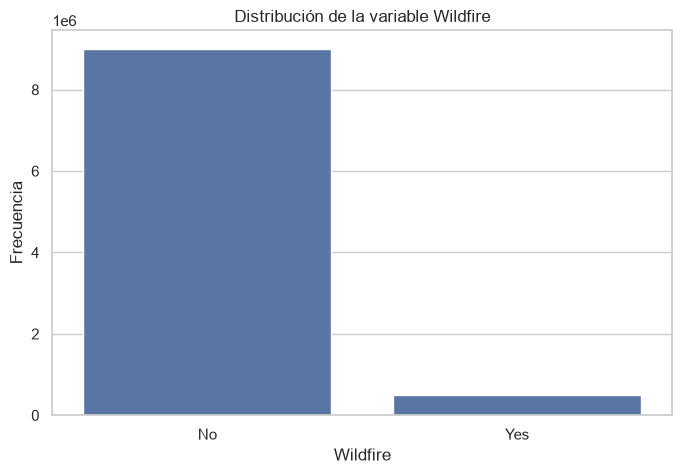

In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Wildfire')
plt.title('Distribución de la variable Wildfire')
plt.xlabel('Wildfire')
plt.ylabel('Frecuencia')
plt.show()

In [9]:
# El dataset está desbalanceado porque hay solo un 5% de incendios
df['Wildfire'].value_counts(normalize=True) * 100

Wildfire
No     94.720621
Yes     5.279379
Name: proportion, dtype: float64

##### La variable objetivo está muy desbalanceada

In [10]:
# Hago una copia para trabajar
df_transformado = df.copy()

# Convierto la columna datetime a formato fecha
df_transformado['datetime'] = pd.to_datetime(
    df_transformado['datetime'], format='%Y-%m-%d'
)

# Convierto la columna Wildfire a formato bool
df_transformado['Wildfire'] = df_transformado['Wildfire'].map({'Yes': 1, 'No': 0})

# Verifico que todo esté bien
print(df_transformado.dtypes)
print("-"*40)
print(df_transformado[df_transformado['Wildfire'] == 1][['datetime', 'Wildfire']].sample(5))
print(df_transformado[df_transformado['Wildfire'] == 0][['datetime', 'Wildfire']].sample(5))

latitude            float64
longitude           float64
datetime     datetime64[us]
Wildfire              int64
pr                  float64
rmax                float64
rmin                float64
sph                 float64
srad                float64
tmmn                float64
tmmx                float64
vs                  float64
bi                  float64
fm100               float64
fm1000              float64
erc                 float64
etr                 float64
pet                 float64
vpd                 float64
dtype: object
----------------------------------------
          datetime  Wildfire
8076512 2018-07-29         1
3496120 2018-10-24         1
6202115 2020-08-02         1
4903492 2023-04-04         1
1550544 2020-04-08         1
          datetime  Wildfire
9443841 2023-07-18         0
3255527 2021-04-04         0
7437039 2015-04-20         0
6681376 2017-03-05         0
8452070 2017-06-19         0


In [11]:
# Reviso los duplicados
print('Duplicados totales: ', df_transformado.duplicated().sum())

# Los elimino
df_transformado = df_transformado.drop_duplicates()
print('Duplicados eliminados.')

# Reviso si fueron eliminados
print('Duplicados restantes: ', df_transformado.duplicated().sum())

Duplicados totales:  13920
Duplicados eliminados.
Duplicados restantes:  0


### Reviso el valor extraño que se repetía tanto en el describe

In [12]:
# Primero voy a crear una máscara para que me muestre solo las filas con ese valor
cols_numericas = df_transformado.select_dtypes(include='number').columns
mascara = (df_transformado[cols_numericas] == 32767).any(axis=1)
print('Filas con valor 32767:', mascara.sum())

Filas con valor 32767: 25725


In [13]:
# Reviso qué porcentaje de estos valores representan un incendio positivo.
print(df_transformado[mascara]['Wildfire'].value_counts())
print(df_transformado[mascara]['Wildfire'].value_counts(normalize=True) * 100)

Wildfire
0    25725
Name: count, dtype: int64
Wildfire
0    100.0
Name: proportion, dtype: float64


##### Los valores representan un 100% de valores negativos, por lo que no tienen ninguna influencia en los incendios.

In [14]:
# Doy un vistazo a las primeras 10 filas y veo que todos los valores salvo fecha, son iguales
df_transformado[mascara].head(10)

,latitude,longitude,datetime,Wildfire,pr,rmax,rmin,sph,srad,tmmn,tmmx,vs,bi,fm100,fm1000,erc,etr,pet,vpd
29100,42.062601,-80.953609,2017-11-17,0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0
29101,42.062601,-80.953609,2017-11-18,0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0
29102,42.062601,-80.953609,2017-11-19,0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0
29103,42.062601,-80.953609,2017-11-20,0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0
29104,42.062601,-80.953609,2017-11-21,0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0
29105,42.062601,-80.953609,2017-11-22,0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0
29106,42.062601,-80.953609,2017-11-23,0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0
29107,42.062601,-80.953609,2017-11-24,0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0
29108,42.062601,-80.953609,2017-11-25,0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0
29109,42.062601,-80.953609,2017-11-26,0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0,32767.0


In [15]:
# Los elimino, quedandome con todos los datos opuestos a la mascara que creé
df_transformado = df_transformado[~mascara]

#### **Conclusión:** Me parece que la mejor idea fue eliminarlos, ya que al ser todos datos iguales en la misma ubicación geográfica, estimo que son filas donde el sensor no registró ningún dato válido y se tuvo que rellenar con ese valor que no significa nada, pero puede llegar a afectar al modelo.

## Outliers

In [16]:
# Reviso qué cantidad de datos extremos hay en cada columna
for col in cols_numericas:
    Q1 = df_transformado[col].quantile(0.25)
    Q3 = df_transformado[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df_transformado[col] < Q1 - 1.5 * IQR) | (df_transformado[col] > Q3 + 1.5 * IQR)).sum()
    print(f'{col}: {outliers} outliers ({outliers/len(df_transformado)*100:.2f}%)')

latitude: 0 outliers (0.00%)
longitude: 0 outliers (0.00%)
Wildfire: 501032 outliers (5.29%)
pr: 2305992 outliers (24.35%)
rmax: 1158 outliers (0.01%)
rmin: 80430 outliers (0.85%)
sph: 321346 outliers (3.39%)
srad: 0 outliers (0.00%)
tmmn: 142458 outliers (1.50%)
tmmx: 89491 outliers (0.94%)
vs: 312679 outliers (3.30%)
bi: 83821 outliers (0.89%)
fm100: 4906 outliers (0.05%)
fm1000: 28450 outliers (0.30%)
erc: 562 outliers (0.01%)
etr: 60606 outliers (0.64%)
pet: 13887 outliers (0.15%)
vpd: 285422 outliers (3.01%)


In [17]:
# Muestro el porcentaje de True Wildfires que hay en esos valores extremos
for col in cols_numericas:
    Q1 = df_transformado[col].quantile(0.25)
    Q3 = df_transformado[col].quantile(0.75)
    IQR = Q3 - Q1
    mascara_outlier = (df_transformado[col] < Q1 - 1.5 * IQR) | (df_transformado[col] > Q3 + 1.5 * IQR)
    total = mascara_outlier.sum()
    if total > 0:
        pct_wildfire = df_transformado[mascara_outlier]['Wildfire'].mean() * 100
        print(f'{col}: {total} outliers - {pct_wildfire:.2f}% son incendios')

Wildfire: 501032 outliers - 100.00% son incendios
pr: 2305992 outliers - 4.63% son incendios
rmax: 1158 outliers - 13.39% son incendios
rmin: 80430 outliers - 3.96% son incendios
sph: 321346 outliers - 2.93% son incendios
tmmn: 142458 outliers - 1.68% son incendios
tmmx: 89491 outliers - 1.63% son incendios
vs: 312679 outliers - 4.79% son incendios
bi: 83821 outliers - 6.77% son incendios
fm100: 4906 outliers - 3.30% son incendios
fm1000: 28450 outliers - 2.17% son incendios
erc: 562 outliers - 5.69% son incendios
etr: 60606 outliers - 8.25% son incendios
pet: 13887 outliers - 8.94% son incendios
vpd: 285422 outliers - 7.75% son incendios


#### **Conclusión:** Mi desición final fue **no eliminarlos**. pr (precipitación) es el más llamativo ya que hay un 24.35% de valores extremos, pero que hayan muchos días sin lluvia y pocos con mucha lluvia es algo normal, por lo que no creo que sean outliers. El resto están todos por debajo del 4% y son variables climáticas donde los extremos tienen sentido. Así que dicidí ver qué porcentaje de True Wildfires hay en esos valores extremos. Estos outliers no son errores, sino fenómenos climáticos reales con cierta correlación con los incendios, por lo tanto los conservo.

In [18]:
# Creo las columnas año, mes y día a partir de la columna datetime y luego la elimino.
from datetime import date

df_transformado['anio'] = df_transformado['datetime'].dt.year
df_transformado['mes'] = df_transformado['datetime'].dt.month
df_transformado['dia'] = df_transformado['datetime'].dt.day
df_transformado = df_transformado.drop(columns=['datetime'])

In [19]:
display(df_transformado.head())

,latitude,longitude,Wildfire,pr,rmax,rmin,sph,srad,tmmn,tmmx,vs,bi,fm100,fm1000,erc,etr,pet,vpd,anio,mes,dia
0,48.128431,-97.276685,0,0.0,78.6,14.9,0.00582,272.6,282.0,301.6,3.0,40.0,10.2,12.2,54.0,7.5,5.5,1.59,2018,8,15
1,48.128431,-97.276685,0,0.0,80.4,13.9,0.00676,264.0,283.9,304.9,3.0,40.0,9.7,12.0,56.0,8.2,5.9,1.93,2018,8,16
2,48.128431,-97.276685,0,0.0,70.9,20.4,0.00672,265.6,285.8,300.7,3.1,40.0,9.2,11.9,56.0,7.2,5.3,1.51,2018,8,17
3,48.128431,-97.276685,0,5.0,65.2,19.4,0.00756,261.4,289.0,303.3,5.1,0.0,9.9,12.0,40.0,10.0,6.9,1.85,2018,8,18
4,48.128431,-97.276685,0,0.0,100.0,42.2,0.00895,166.8,283.8,296.5,4.7,41.0,11.8,12.1,47.0,4.6,3.4,0.66,2018,8,19


In [20]:
# Muestro las correlaciones entre las columnas y la variable objetivo para saber cuales usar como variables predictoras
correlaciones = df_transformado.corr()['Wildfire'].sort_values(ascending=False)
print(correlaciones)

Wildfire     1.000000
anio         0.141589
erc          0.056714
bi           0.038504
vpd          0.036856
tmmx         0.033501
tmmn         0.031968
mes          0.027924
etr          0.023800
pet          0.018691
dia         -0.000099
srad        -0.000705
sph         -0.004476
pr          -0.006999
vs          -0.017700
latitude    -0.029841
rmax        -0.032374
rmin        -0.035059
fm100       -0.043596
longitude   -0.050701
fm1000      -0.067759
Name: Wildfire, dtype: float64


##### La correlación con las columnas es muy mala, por lo que ya me estoy esperando que el modelo no va a ser muy bueno

In [21]:
# Voy a sacar año, a pesar de que tiene la correlación más alta, ya que no es parámetro. Porque hay años donde hubo más incendios que otros y eso puede introducir un sesgo temporal
variables_predictoras = ['mes', 'erc', 'bi', 'vpd', 'tmmx', 'tmmn', 'etr', 'pet',
            'fm1000', 'fm100', 'rmin', 'rmax', 'latitude', 'longitude']

variable_objetivo = 'Wildfire'

X = df_transformado[variables_predictoras]
y = df_transformado[variable_objetivo]

print('Variables predictoras seleccionadas:')
print(variables_predictoras)

print('\nVariable objetivo:')
print(variable_objetivo)

print('\nDimensiones de X:', X.shape)
print('Dimensiones de y:', y.shape)

display(X.head())
display(y.head())

Variables predictoras seleccionadas:
['mes', 'erc', 'bi', 'vpd', 'tmmx', 'tmmn', 'etr', 'pet', 'fm1000', 'fm100', 'rmin', 'rmax', 'latitude', 'longitude']

Variable objetivo:
Wildfire

Dimensiones de X: (9470280, 14)
Dimensiones de y: (9470280,)


,mes,erc,bi,vpd,tmmx,tmmn,etr,pet,fm1000,fm100,rmin,rmax,latitude,longitude
0,8,54.0,40.0,1.59,301.6,282.0,7.5,5.5,12.2,10.2,14.9,78.6,48.128431,-97.276685
1,8,56.0,40.0,1.93,304.9,283.9,8.2,5.9,12.0,9.7,13.9,80.4,48.128431,-97.276685
2,8,56.0,40.0,1.51,300.7,285.8,7.2,5.3,11.9,9.2,20.4,70.9,48.128431,-97.276685
3,8,40.0,0.0,1.85,303.3,289.0,10.0,6.9,12.0,9.9,19.4,65.2,48.128431,-97.276685
4,8,47.0,41.0,0.66,296.5,283.8,4.6,3.4,12.1,11.8,42.2,100.0,48.128431,-97.276685


0    0
1    0
2    0
3    0
4    0
Name: Wildfire, dtype: int64

## División estratificada de los datos

La división entre entrenaimento y prueba es practicamente la misma proporción que tenía el dataset original gracias a stratify=y

In [22]:
# Divido los datos en entrenamiento y prueba
# Uso el 80% de los datos para entrenar el modelo y el 20% para evaluar el rendimiento

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print('Dimensiones de X_train:', X_train.shape)
print('Dimensiones de X_test:', X_test.shape)
print('Dimensiones de y_train:', y_train.shape)
print('Dimensiones de y_test:', y_test.shape)

print('\nDistribuciones de clases en y_train:')
display(y_train.value_counts(normalize=True) * 100)

print('\nDistribución de clases en y_test:')
display(y_test.value_counts(normalize=True) * 100)

Dimensiones de X_train: (6629196, 14)
Dimensiones de X_test: (2841084, 14)
Dimensiones de y_train: (6629196,)
Dimensiones de y_test: (2841084,)

Distribuciones de clases en y_train:


Wildfire
0    94.709434
1     5.290566
Name: proportion, dtype: float64


Distribución de clases en y_test:


Wildfire
0    94.709414
1     5.290586
Name: proportion, dtype: float64

## Construcción del preprocesamiento

In [23]:
# Identificamos las columnas numéricas

columnas_numericas = X_train.columns

# Transformador para variables numéricas
transformador_numerico = Pipeline(
    steps=[
        ("imputador", SimpleImputer(strategy="median")), # Por si hay valores faltantes
        ("escalador", StandardScaler())
    ]
)

# Mostramos la cantidad de columnas numéricas
print("Cantidad de columnas numéricas:", len(columnas_numericas))

Cantidad de columnas numéricas: 14


In [24]:
# ---------------------------------------------------------
# Construcción del preprocesamiento
# ---------------------------------------------------------

# Transformador general:
# - escala columnas numéricas
preprocesamiento = ColumnTransformer(
    transformers=[
        ("numericas", transformador_numerico, columnas_numericas)
    ]
)

print("Preprocesador creado:")
print(preprocesamiento)

Preprocesador creado:
ColumnTransformer(transformers=[('numericas',
                                 Pipeline(steps=[('imputador',
                                                  SimpleImputer(strategy='median')),
                                                 ('escalador',
                                                  StandardScaler())]),
                                 Index(['mes', 'erc', 'bi', 'vpd', 'tmmx', 'tmmn', 'etr', 'pet', 'fm1000',
       'fm100', 'rmin', 'rmax', 'latitude', 'longitude'],
      dtype='str'))])


## Creación de pipeline

In [25]:
# ---------------------------------------------------------
# Creación del pipeline completo
# ---------------------------------------------------------

# Creamos el modelo que usaremos al final del pipeline
# Acá uso 1000 iteraciones
modelo_logistico = LogisticRegression(
    max_iter=1000,
    class_weight='balanced', # Pongo balanced ya que la variable objetivo tiene una distribución desbalanceada
    random_state=42
)

# Creamos el pipeline completo
pipeline_lr = Pipeline(
    steps=[
        ("preprocesamiento", preprocesamiento),
        ("modelo", modelo_logistico)
    ]
)

# Entrenamos el pipeline completo
pipeline_lr.fit(X_train, y_train)

print("Modelo de Regresión Logística entrenado correctamente.")

Modelo de Regresión Logística entrenado correctamente.


In [26]:
# Realizo predicciones con el modelo

y_pred = pipeline_lr.predict(X_test)
y_proba = pipeline_lr.predict_proba(X_test)

print('Primeras 25 clases reales:')
print(y_test.values[:25])

print('\nPrimeras 25 clases predichas:')
print(y_pred[:25])

print('\nPrimeras 25 probabilidades estimadas:')
display(pd.DataFrame(
    y_proba[:25],
    columns=['Probabilidad incendio positivo', 'Probabilidad incendio negativo']
))

Primeras 25 clases reales:
[0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Primeras 25 clases predichas:
[0 0 1 1 0 0 0 0 0 1 1 0 0 0 0 1 0 1 0 0 0 1 0 0 0]

Primeras 25 probabilidades estimadas:


,Probabilidad incendio positivo,Probabilidad incendio negativo
0,0.532044,0.467956
1,0.771973,0.228027
2,0.481750,0.518250
3,0.428915,0.571085
4,0.624292,0.375708
5,0.601558,0.398442
6,0.616924,0.383076
7,0.524620,0.475380
8,0.557060,0.442940
9,0.404210,0.595790


##### Acá ya estoy notando que el modelo está prediciendo muchos falsos positivos

In [27]:
# Calculo el accuracy del modelo

accuracy = accuracy_score(y_test, y_pred)

print('Accuracy del modelo:', accuracy)
print(f'Accuracy del modelo: {accuracy:.2%}')

Accuracy del modelo: 0.5760783560077773
Accuracy del modelo: 57.61%


#### Pésimo accuracy. Sospecho que es porque todas las variables predictivas tenían poca correlación con la variable objetivo :(

In [28]:
# Calculo precisión, reacall y F1-SCORE

reporte = classification_report(
    y_test,
    y_pred,
    target_names=["Incendio negativo", "Incendio positivo"]
)

print(reporte)

                   precision    recall  f1-score   support

Incendio negativo       0.96      0.58      0.72   2690774
Incendio positivo       0.07      0.59      0.13    150310

         accuracy                           0.58   2841084
        macro avg       0.52      0.58      0.42   2841084
     weighted avg       0.91      0.58      0.69   2841084



- **Accuracy (58%):** De todos los casos, ¿cuántos calificó bien?. Es la métrica más engañosa, ya que es un dataset que tiene un 95% de negativos. Un modelo que predice siempre "No incendio" puede tener un accuracy muy alto y aun así no aprender nada útil.

- **Precisión (7%):** De todos los que predijo como positivo, ¿cuántos realmente lo eran?. 7% es muy bajo, significa que el modelo detecta muchísimos falsos positivos.

- **Recall (59%):** De todos los positivos, ¿Cuántos realmente lo eran?. En este caso, la métrica más importante ya que el costo de no detectar un positivo real es el más alto. 59% es la métrica más alta, pero sigue siendo un número bajo.

- **F1-score (13%):** Promedio entre precisión y recall. 13% es muy bajo.

**Conclusión:** Es un modelo muy débil. No es bueno prediciendo.

In [29]:
# Validación cruzada

scores_recall = cross_val_score(pipeline_lr, X_train, y_train, cv=5, scoring='recall')
scores_precision = cross_val_score(pipeline_lr, X_train, y_train, cv=5, scoring='precision')
scores_f1 = cross_val_score(pipeline_lr, X_train, y_train, cv=5, scoring='f1')

print(f"Recall por fold: {scores_recall}")
print(f"Recall promedio: {scores_recall.mean():.3f} (+/- {scores_recall.std():.3f})")

print(f"Precision por fold: {scores_precision}")
print(f"Precision promedio: {scores_precision.mean():.3f} (+/- {scores_precision.std():.3f})")

print(f"F1 por fold: {scores_f1}")
print(f"F1 promedio: {scores_f1.mean():.3f} (+/- {scores_f1.std():.3f})")

Recall por fold: [0.59285765 0.59058508 0.59658702 0.59375    0.59617934]
Recall promedio: 0.594 (+/- 0.002)
Precision por fold: [0.07239903 0.07209738 0.07272111 0.07240234 0.07258945]
Precision promedio: 0.072 (+/- 0.000)
F1 por fold: [0.12903987 0.12850691 0.12963976 0.12906625 0.1294209 ]
F1 promedio: 0.129 (+/- 0.000)


La validación cruzada (5 folds) confirma que las métricas obtenidas en el test set no fueron producto del azar:

- **Recall: 0.594 (± 0.002):** El modelo detecta ~59% de los incendios reales de forma consistente entre folds. La desviación mínima indica que este comportamiento es estable, no depende del split de datos.
- **Precision: 0.072 (± 0.000):** De cada 100 predicciones de "Wildfire", solo ~7 son correctas. Es decir, el modelo genera muchas falsas alarmas.
- **F1-score: 0.129 (± 0.000):** Bajo, como consecuencia directa del desbalance entre recall y precision.

Matriz de confusión:
[[1547529 1143245]
 [  61152   89158]]


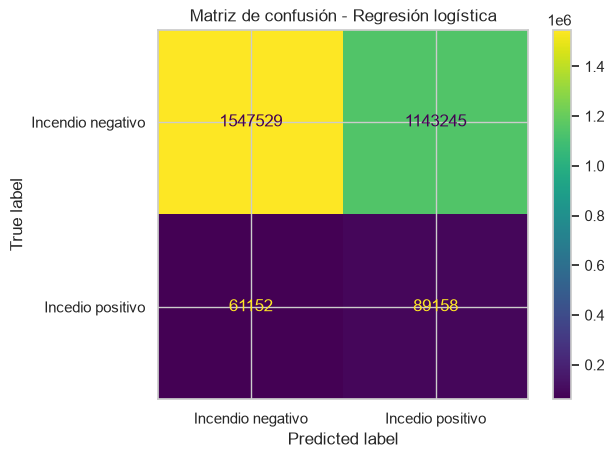

In [30]:
# Calculo y grafico la matriz de confusión

matriz = confusion_matrix(y_test, y_pred)

print("Matriz de confusión:")
print(matriz)

# Muestro la matriz como gráfico

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=["Incendio negativo", "Incedio positivo"]
)

disp.plot(values_format="d")
plt.title("Matriz de confusión - Regresión logística")
plt.show()

In [31]:
# ==========================================================
# CALCULAMOS MÉTRICAS A PARTIR DE LA MATRIZ DE CONFUSIÓN
# ==========================================================
# Extraemos los valores de la matriz.
#
# La matriz tiene esta estructura:
#
# [[VN, FP],
# [FN, VP]]
VN, FP, FN, VP = matriz.ravel()
print("Verdaderos negativos (VN):", VN)
print("Falsos positivos (FP):", FP)
print("Falsos negativos (FN):", FN)
print("Verdaderos positivos (VP):", VP)
# ----------------------------------------------------------
# Calculamos precision y recall para la clase positiva
# ----------------------------------------------------------
precision_positiva = VP / (VP + FP)
recall_positivo = VP / (VP + FN)
f1_positivo = 2 * (precision_positiva * recall_positivo) / (precision_positiva + recall_positivo)

print("\nMétricas para la clase positiva:")
print(f"Precision: {precision_positiva:.2f}")
print(f"Recall: {recall_positivo:.2f}")
print(f"F1-score: {f1_positivo:.2f}")

Verdaderos negativos (VN): 1547529
Falsos positivos (FP): 1143245
Falsos negativos (FN): 61152
Verdaderos positivos (VP): 89158

Métricas para la clase positiva:
Precision: 0.07
Recall: 0.59
F1-score: 0.13


|  | Predicho: No incendio | Predicho: Incendio |
|---|---|---|
| **Real: No incendio** | 1.547.529 ✅ (Verdadero Negativo) | 1.143.245 ❌ (Falso Positivo) |
| **Real: Incendio** | 61.152 ❌ (Falso Negativo) | 89.158 ✅ (Verdadero Positivo) |

**Interpretación:**
- El modelo detectó correctamente **89.158 incendios reales** (Verdaderos Positivos)
- Sin embargo, generó **1.143.245 falsas alarmas** (Falsos Positivos) — casos clasificados como incendio que no lo eran
- Dejó sin detectar **61.152 incendios reales** (Falsos Negativos)

> Dado que el costo de no detectar un incendio real es muy alto, el **recall** es la métrica más relevante para este problema. El modelo alcanza un recall de **59%**, lo que significa que detecta poco más de la mitad de los incendios reales.

In [32]:
# ==========================================================
# PROBAMOS DISTINTOS UMBRALES DE DECISIÓN
# ==========================================================

# Tomamos solamente la probabilidad de la clase positiva.
# Es decir, la probabilidad de que sí haya incendio.
probabilidad_clase_positiva = y_proba[:, 1]
umbrales = [0.3, 0.4, 0.5, 0.6, 0.7]
resultados_umbrales = []
for umbral in umbrales:
    # Si la probabilidad de clase positiva supera el umbral,
    # clasificamos el caso como 1. Si no, como 0.
    y_pred_umbral = (probabilidad_clase_positiva >= umbral).astype(int)

    precision = precision_score(y_test, y_pred_umbral)
    recall = recall_score(y_test, y_pred_umbral)
    f1 = f1_score(y_test, y_pred_umbral)

    resultados_umbrales.append({
        "umbral": umbral,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
})
resultados_umbrales = pd.DataFrame(resultados_umbrales)
display(resultados_umbrales)

,umbral,precision,recall,f1_score
0,0.3,0.055032,0.984732,0.104239
1,0.4,0.061773,0.885171,0.115487
2,0.5,0.072345,0.593161,0.128961
3,0.6,0.085759,0.239046,0.126232
4,0.7,0.101008,0.025407,0.040602


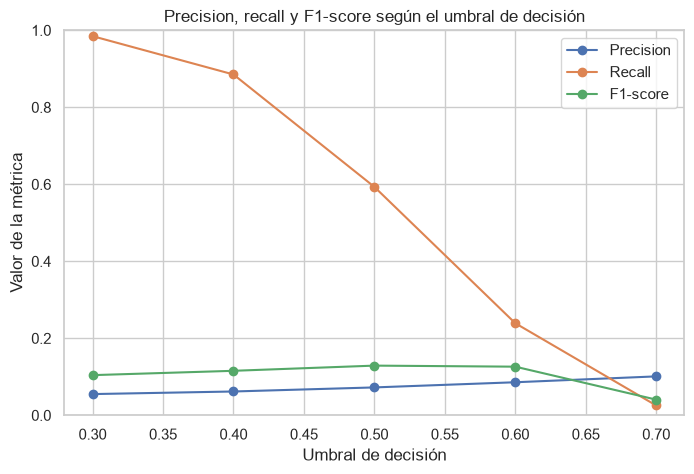

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(resultados_umbrales["umbral"], resultados_umbrales["precision"], marker="o", label="Precision")
plt.plot(resultados_umbrales["umbral"], resultados_umbrales["recall"], marker="o", label="Recall")
plt.plot(resultados_umbrales["umbral"], resultados_umbrales["f1_score"], marker="o", label="F1-score")

plt.title("Precision, recall y F1-score según el umbral de decisión")
plt.xlabel("Umbral de decisión")
plt.ylabel("Valor de la métrica")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

El umbral de decisión define a partir de qué probabilidad el modelo clasifica un caso como incendio.
Por defecto es 0.5, pero puede ajustarse según lo que se quiera priorizar.

| Umbral | Precision | Recall | F1-score |
|--------|-----------|--------|----------|
| 0.3 | 5.5% | 98.5% | 10.4% |
| 0.4 | 6.2% | 88.5% | 11.5% |
| 0.5 | 7.2% | 59.3% | 12.9% |
| 0.6 | 8.6% | 23.9% | 12.6% |
| 0.7 | 10.1% | 2.5% | 4.0% |

**Interpretación:**
- A medida que se **sube el umbral**, la precision aumenta levemente pero el recall cae drásticamente
- El **mejor F1-score se obtiene en 0.5**, el umbral por defecto
- No existe un umbral que mejore significativamente ambas métricas a la vez, esto indica que la limitación es estructural: las variables predictoras no tienen suficiente poder predictivo.

Tal vez en un contexto real de detección de incendios, podría preferirse un umbral bajo (como 0.3) para maximizar el recall y detectar la mayor cantidad posible de incendios reales, aceptando más falsas alarmas

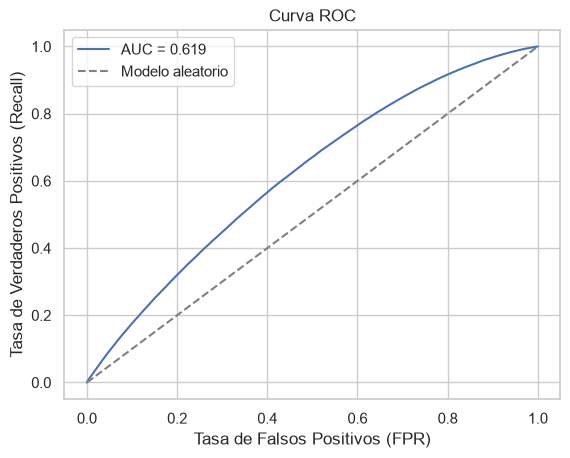

AUC: 0.619


In [34]:
# ==================
# CURVA ROC Y AUC
# ==================

y_proba = pipeline_lr.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Modelo aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curva ROC')
plt.legend()
plt.show()

print(f"AUC: {auc:.3f}")

## Interpretación de la Curva ROC

**AUC = 0.619**

El modelo tiene poder predictivo real, pero débil. Está por encima del azar (0.5), lejos de un modelo bueno (>0.8).

- La curva se separa de la diagonal en todo el rango, confirmando que el modelo distingue algo entre clases, no es puro ruido.
- 0.619 es consistente con lo ya observado: correlaciones bajas entre predictores y target.
- La curva se aplana en la zona de FPR alto (0.6-1.0): ganar recall adicional ahí cuesta cada vez más falsos positivos. Eso también contextualiza por qué la precision es tan baja en cualquier threshold razonable.

## **Conclusión del informe**
- El dataset no es del todo apto para el problema debido a las bajas correlaciones y un AUC de 0.619.
- Con 59% de recall, 4 de cada 10 incendios reales quedan sin detectar. No es aceptable para un sistema real.
- Con un 7% de precisión en un sistema real de alerta de incendios, se generarían alarmas falsas constantemente. Esto tiene un costo operativo enorme que tampoco es aceptable.
- El modelo captura señal real pero limitada. La causa no es el algoritmo (Logistic Regression) ni el threshold, es la capacidad predictiva de las variables disponibles. Mejorar esto requiere feature engineering adicional o un dataset con variables más correlacionadas al target, no ajustar hiperparámetros del modelo actual.